<a href="https://colab.research.google.com/github/Shehbaaz11/ATM_interface_javaproject/blob/main/AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io

uploaded = files.upload()



Saving diabetic_data.csv to diabetic_data.csv


In [ ]:
!pip install lightgbm shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv('diabetic_data.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (101766, 50)

First few rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("Dataset info:")
print(df.info())

print("\nTarget variable distribution:")
print(df['readmitted'].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  in

In [ ]:
df['target'] = (df['readmitted'] == '<30').astype(int)

print("New target distribution:")
print(df['target'].value_counts())
print("\nPercentage of readmissions within 30 days: {:.2f}%".format(df['target'].mean() * 100))

New target distribution:
target
0    90409
1    11357
Name: count, dtype: int64

Percentage of readmissions within 30 days: 11.16%


In [ ]:
cols_to_drop = ['encounter_id', 'patient_nbr', 'readmitted']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

df_clean = df_clean.replace('?', np.nan)

print("Data shape after cleaning:", df_clean.shape)

Data shape after cleaning: (101766, 48)


In [ ]:

cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", len(cat_cols))
print("Numerical columns:", len(num_cols))

X = df_clean[num_cols].copy()
y = df['target']

if 'target' in X.columns:
    X = X.drop('target', axis=1)

print("Final feature shape:", X.shape)
print("Available features:", X.columns.tolist())

Categorical columns: 36
Numerical columns: 12
Final feature shape: (101766, 11)
Available features: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [ ]:
X = X.fillna(X.median())

print("Missing values after handling:", X.isnull().sum().sum())

Missing values after handling: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Readmission rate in train: {:.2f}%".format(y_train.mean() * 100))
print("Readmission rate in test: {:.2f}%".format(y_test.mean() * 100))

Training set shape: (81412, 11)
Test set shape: (20354, 11)
Readmission rate in train: 11.16%
Readmission rate in test: 11.16%


In [ ]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_eval = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'seed': 42,
    'verbose': -1
}

print("Training LightGBM model...")
bst = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_eval],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

print("Training completed!")
print(f"Best iteration: {bst.best_iteration}")

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[100]	training's auc: 0.69413	valid_1's auc: 0.679015
Early stopping, best iteration is:
[148]	training's auc: 0.70264	valid_1's auc: 0.679539
Training completed!
Best iteration: 148


=== MODEL PERFORMANCE ===
AUROC: 0.6795
AUPRC: 0.2266

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.59      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.74      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354



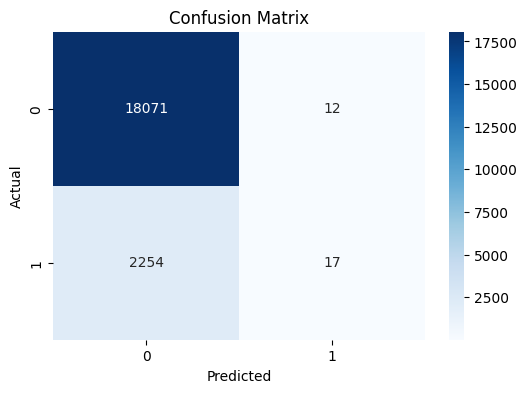

In [ ]:
# Make predictions
y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)

# Calculate metrics
auc = roc_auc_score(y_test, y_pred)
auprc = average_precision_score(y_test, y_pred)

print("=== MODEL PERFORMANCE ===")
print("AUROC: {:.4f}".format(auc))
print("AUPRC: {:.4f}".format(auprc))

y_pred_binary = (y_pred > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Generating SHAP explanations...
SHAP values calculated!


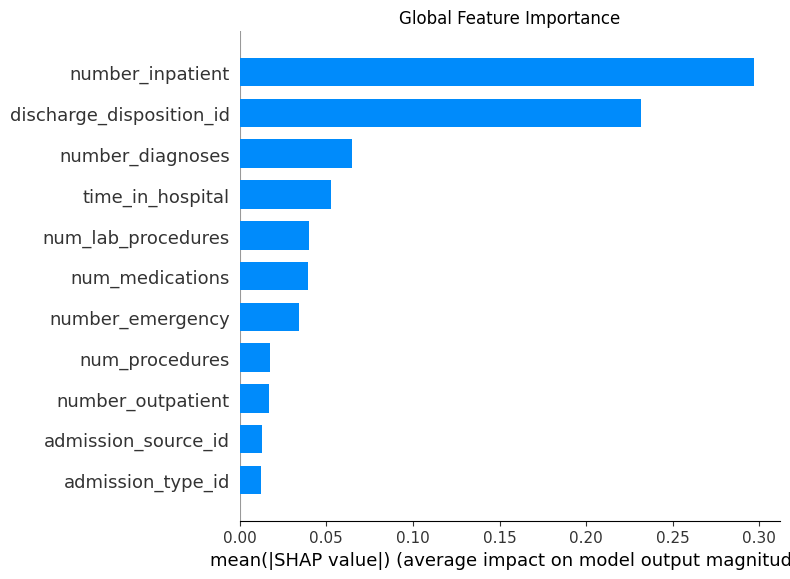

In [ ]:
print("Generating SHAP explanations...")

# Create SHAP explainer
explainer = shap.TreeExplainer(bst)

sample_size = min(1000, len(X_test))
X_sample = X_test.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated!")


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance")
plt.tight_layout()
plt.show()

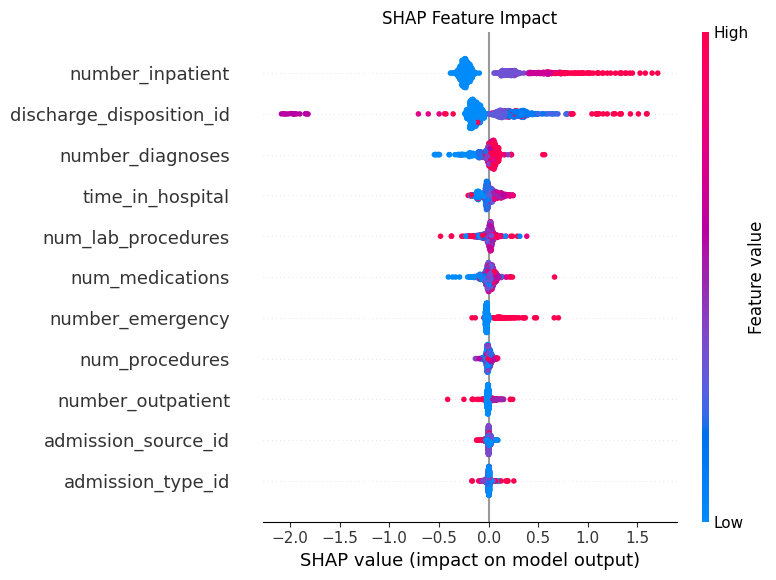

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Impact")
plt.tight_layout()
plt.show()

Explaining individual predictions...
Patient prediction: 0.1225 (Low Risk)
Actual outcome: 0


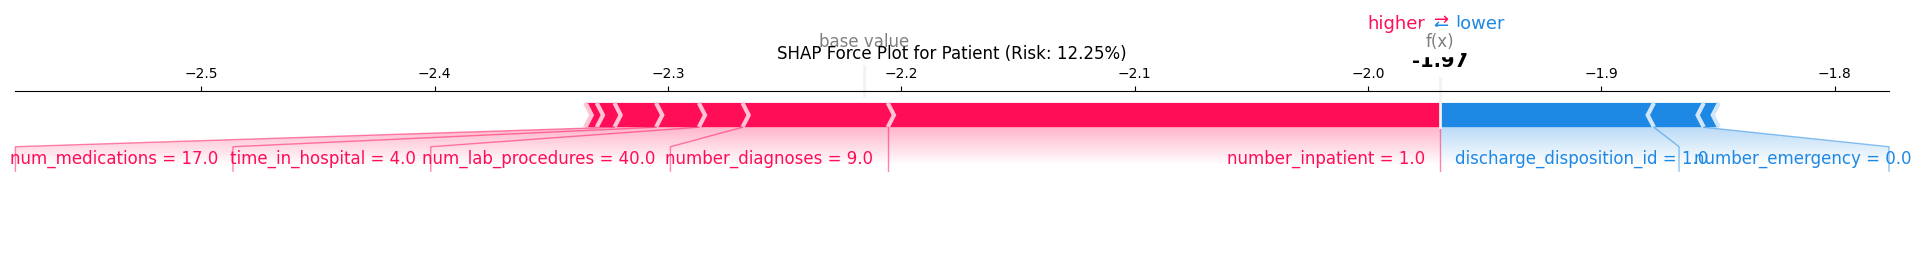

In [ ]:

print("Explaining individual predictions...")


patient_idx = 0
patient_data = X_sample.iloc[patient_idx:patient_idx+1]


patient_pred = bst.predict(patient_data, num_iteration=bst.best_iteration)[0]

print(f"Patient prediction: {patient_pred:.4f} ({'High Risk' if patient_pred > 0.5 else 'Low Risk'})")
print(f"Actual outcome: {y_test.iloc[patient_idx]}")


shap.force_plot(
    explainer.expected_value,
    shap_values[patient_idx, :],
    patient_data.iloc[0],
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot for Patient (Risk: {patient_pred:.2%})")
plt.tight_layout()
plt.show()

In [ ]:
import joblib


joblib.dump(bst, 'readmission_model.pkl')
print("Model saved successfully!")

explainer = shap.TreeExplainer(bst)
joblib.dump(explainer, 'shap_explainer.pkl')
print("SHAP explainer saved successfully!")


X_sample = X_test.iloc[:100]
y_sample = y_test.iloc[:100]
sample_data = X_sample.copy()
sample_data['predicted_risk'] = bst.predict(X_sample, num_iteration=bst.best_iteration)
sample_data['actual_readmission'] = y_sample.values

sample_data.to_csv('sample_data.csv', index=False)
print("Sample data saved successfully!")

from google.colab import files
files.download('readmission_model.pkl')
files.download('shap_explainer.pkl')
files.download('sample_data.csv')

print("All files downloaded! Check your downloads folder.")

Model saved successfully!
SHAP explainer saved successfully!
Sample data saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded! Check your downloads folder.
